# EDA — CIS 2450 Final Project
Exploratory Data Analysis for the academic paper similarity project.

Goal: understand the shape, distributions, and quirks of our data before building the K-Means model.

## 1. Load Data

In [3]:
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DB_PATH = Path("../papers.db")

conn = sqlite3.connect(DB_PATH)

# Join OpenAlex (spine) with Semantic Scholar (tldr + abstract) on doi_normalized
df = pl.read_database(
    query="""
        SELECT
            o.*,
            s.tldr_text,
            s.abstract_text,
            s.s2_found
        FROM openalex_papers o
        LEFT JOIN semanticscholar_papers s
            ON o.doi_normalized = s.doi_normalized
    """,
    connection=conn
)

conn.close()

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 85415, Columns: 14


openalex_id,doi,doi_normalized,title,publication_year,cited_by_count,author_count,primary_topic,primary_subfield,primary_field,primary_domain,tldr_text,abstract_text,s2_found
str,str,str,str,i64,i64,i64,str,str,str,str,str,str,i64
"""https://openalex.org/W43627070…","""https://doi.org/10.1016/j.patc…","""10.1016/j.patcog.2026.113208""","""RFAConv: Receptive-field atten…",2026,86,7,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""Computer Science""","""Physical Sciences""","""It is revealed that current sp…","""In the realm of deep learning,…",1
"""https://openalex.org/W71405085…","""https://doi.org/10.1145/373130…","""10.1145/3731302""","""Science of Software Product Li…",2026,31,1,"""Advanced Software Engineering …","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""",null,null,1
"""https://openalex.org/W71180855…","""https://doi.org/10.1007/s41019…","""10.1007/s41019-025-00335-5""","""Retrieval-Augmented Generation…",2026,28,10,"""Topic Modeling""","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""",null,null,0
"""https://openalex.org/W71290307…","""https://doi.org/10.1145/379651…","""10.1145/3796519""","""Model Context Protocol (MCP): …",2026,22,4,"""Security and Verification in C…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""A comprehensive threat taxonom…","""The Model Context Protocol (MC…",1
"""https://openalex.org/W71360594…","""https://doi.org/10.5281/zenodo…","""10.5281/zenodo.18935892""","""The Sovereign One The Human Pr…",2026,18,1,"""Artificial Intelligence Applic…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""",null,null,0


## 2. Basic Info
Get a high-level sense of the data: column types, how many nulls exist.

In [4]:
# Column types
print(df.dtypes)
print()

# Null counts per column
print("Null counts:")
print(df.null_count())

[String, String, String, String, Int64, Int64, Int64, String, String, String, String, String, String, Int64]

Null counts:
shape: (1, 14)
┌─────────────┬─────┬──────────────┬───────┬───┬──────────────┬───────────┬─────────────┬──────────┐
│ openalex_id ┆ doi ┆ doi_normaliz ┆ title ┆ … ┆ primary_doma ┆ tldr_text ┆ abstract_te ┆ s2_found │
│ ---         ┆ --- ┆ ed           ┆ ---   ┆   ┆ in           ┆ ---       ┆ xt          ┆ ---      │
│ u32         ┆ u32 ┆ ---          ┆ u32   ┆   ┆ ---          ┆ u32       ┆ ---         ┆ u32      │
│             ┆     ┆ u32          ┆       ┆   ┆ u32          ┆           ┆ u32         ┆          │
╞═════════════╪═════╪══════════════╪═══════╪═══╪══════════════╪═══════════╪═════════════╪══════════╡
│ 0           ┆ 0   ┆ 0            ┆ 0     ┆ … ┆ 0            ┆ 67077     ┆ 65326       ┆ 0        │
└─────────────┴─────┴──────────────┴───────┴───┴──────────────┴───────────┴─────────────┴──────────┘


In [5]:
# Summary statistics for numeric columns
df.select(["cited_by_count", "author_count"]).describe()

statistic,cited_by_count,author_count
str,f64,f64
"""count""",85415.0,85415.0
"""null_count""",0.0,0.0
"""mean""",0.097255,3.131897
"""std""",2.944207,2.79027
"""min""",0.0,0.0
"""25%""",0.0,1.0
"""50%""",0.0,3.0
"""75%""",0.0,4.0
"""max""",561.0,100.0


**Observations:**
- All OpenAlex columns are fully populated — no nulls in `primary_topic`, `primary_subfield`, or `doi_normalized`.
- The Semantic Scholar columns (`tldr_text`, `abstract_text`, `s2_found`) will show nulls for papers not matched in S2 — this is expected given the LEFT JOIN and is covered in section 8.
- `cited_by_count` ranges from 0 to 561 with a mean of ~0.1 and a **median of 0**. Almost all papers are uncited, which makes sense since these are all 2026 papers with little time to accumulate citations.
- `author_count` ranges from 0 to 100 with a median of 3 and a mean of ~3.1 — a reasonable distribution.

## 3. Citation Count Distribution
Citation counts are almost always heavily skewed — a few papers get cited a lot, most get cited very little. This matters for modeling because K-Means is sensitive to scale.

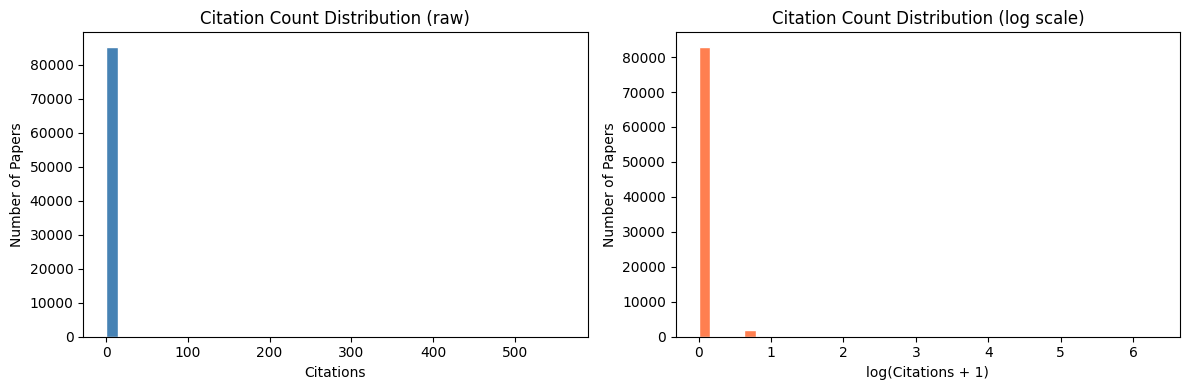

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

citations = df["cited_by_count"].to_list()

axes[0].hist(citations, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Citation Count Distribution (raw)")
axes[0].set_xlabel("Citations")
axes[0].set_ylabel("Number of Papers")

import numpy as np
log_citations = [np.log1p(c) for c in citations]  # log1p handles zeros
axes[1].hist(log_citations, bins=40, color="coral", edgecolor="white")
axes[1].set_title("Citation Count Distribution (log scale)")
axes[1].set_xlabel("log(Citations + 1)")
axes[1].set_ylabel("Number of Papers")

plt.tight_layout()
plt.show()

**Observations:**
- The raw distribution is extremely right-skewed — the median is 0, meaning the majority of papers have zero citations. A small tail of papers has up to 561 citations.
- Log-scaling (`log1p`) makes the nonzero tail more readable, but the fundamental issue is that there's almost no variance — most values are 0.
- **Implication for modeling:** Citation count may be a weak feature for clustering since it carries little signal. Worth keeping for now but flagging as potentially droppable during feature engineering.

## 4. Author Count Distribution

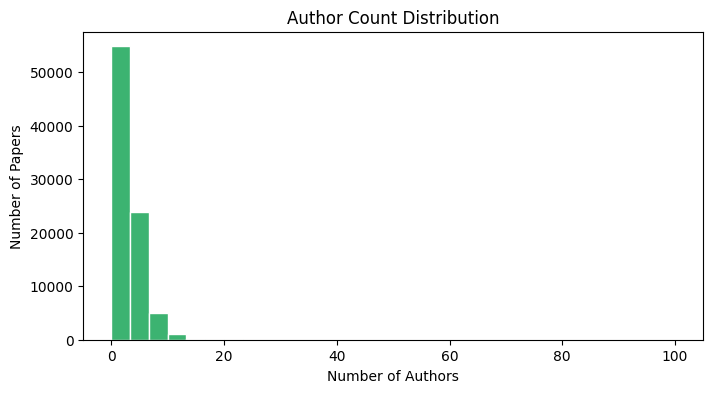

Max authors on one paper: 100
Median authors: 3


In [7]:
author_counts = df["author_count"].to_list()

plt.figure(figsize=(8, 4))
plt.hist(author_counts, bins=30, color="mediumseagreen", edgecolor="white")
plt.title("Author Count Distribution")
plt.xlabel("Number of Authors")
plt.ylabel("Number of Papers")
plt.show()

print(f"Max authors on one paper: {max(author_counts)}")
print(f"Median authors: {sorted(author_counts)[len(author_counts)//2]}")

**Observations:**
- Distribution is concentrated in the 1–10 range, with a median of 3 and mean of ~3.1.
- Only 6 papers have 100+ authors (max is exactly 100), so extreme outliers are minimal — not the large physics/genomics-style mega-collaborations that would heavily skew the feature.
- Author count looks like a clean, usable feature with no major preprocessing concerns.

## 5. Topic / Subfield Breakdown
Since we plan to one-hot encode topics, we need to know how many unique topics there are and how evenly distributed they are.

In [8]:
topic_counts = (
    df.group_by("primary_subfield")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)

print(f"Unique subfields: {df['primary_subfield'].n_unique()}")
print()
print(topic_counts)

Unique subfields: 11

shape: (11, 2)
┌─────────────────────────────────┬───────┐
│ primary_subfield                ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Artificial Intelligence         ┆ 35539 │
│ Computer Vision and Pattern Re… ┆ 12505 │
│ Information Systems             ┆ 12092 │
│ Computer Networks and Communic… ┆ 8248  │
│ Computational Theory and Mathe… ┆ 7783  │
│ …                               ┆ …     │
│ Computer Science Applications   ┆ 2447  │
│ Signal Processing               ┆ 1819  │
│ Hardware and Architecture       ┆ 1178  │
│ Software                        ┆ 545   │
│ Computer Graphics and Computer… ┆ 456   │
└─────────────────────────────────┴───────┘


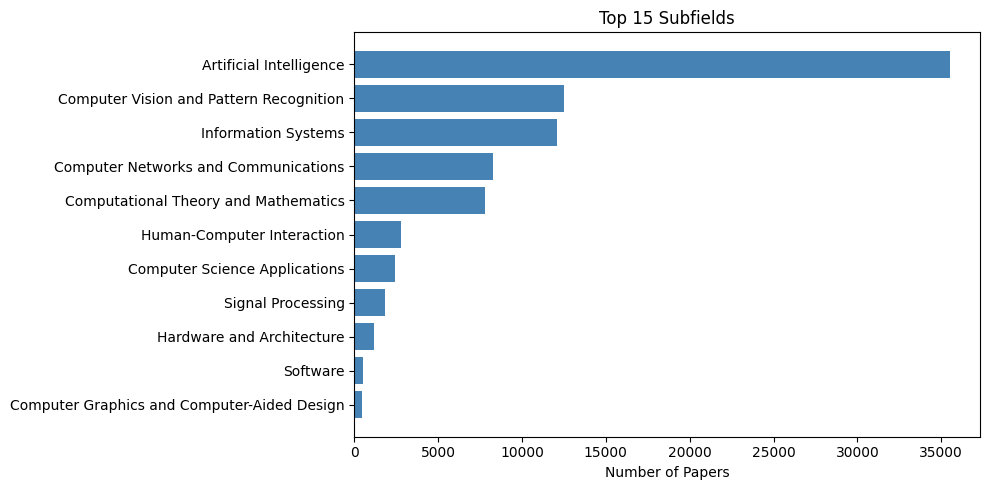

In [9]:
# Bar chart of top 15 subfields
top15 = topic_counts.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top15["primary_subfield"].to_list()[::-1], top15["count"].to_list()[::-1], color="steelblue")
plt.title("Top 15 Subfields")
plt.xlabel("Number of Papers")
plt.tight_layout()
plt.show()

**Observations:**
- Only **11 unique subfields** in total — a very manageable number. No need to collapse rare categories into "Other."
- The top 5 subfields (Artificial Intelligence, Computer Vision and Pattern Recognition, Information Systems, Computer Networks and Communications, Computational Theory and Mathematics) account for ~89% of papers — the distribution is uneven but not problematically so.
- One-hot encoding 11 columns is fine and won't cause the curse of dimensionality on its own.

## 6. Citations vs. Author Count
Do papers with more authors tend to get more citations?

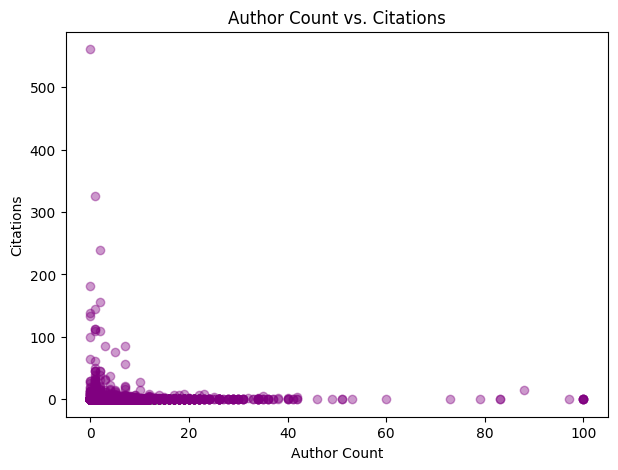

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["author_count"].to_list(),
    df["cited_by_count"].to_list(),
    alpha=0.4,
    color="purple"
)
plt.title("Author Count vs. Citations")
plt.xlabel("Author Count")
plt.ylabel("Citations")
plt.show()

In [ ]:
# Pearson correlation
corr = df.select([
    pl.corr("author_count", "cited_by_count").alias("author_citation_corr")
])
print(corr)

**Observations:**
- Pearson correlation between `author_count` and `cited_by_count` is **-0.0031** — essentially zero.
- No meaningful relationship between the two, and no redundancy concern. Both features can be kept independently.
- The scatter plot will likely show a dense cluster near zero citations across all author counts, consistent with the near-zero citation distribution observed above.

## 7. Missing Value Deep Dive
Check which papers are missing topic info — these rows may need to be dropped before modeling.

In [11]:
missing_topic = df.filter(pl.col("primary_topic").is_null())
print(f"Papers missing primary_topic: {len(missing_topic)}")

missing_subfield = df.filter(pl.col("primary_subfield").is_null())
print(f"Papers missing primary_subfield: {len(missing_subfield)}")

missing_doi = df.filter(pl.col("doi_normalized").is_null())
print(f"Papers missing DOI: {len(missing_doi)}")

Papers missing primary_topic: 0
Papers missing primary_subfield: 0
Papers missing DOI: 0


**Observations:**
- Zero nulls across `primary_topic`, `primary_subfield`, and `doi_normalized` — no rows need to be dropped for missing topic data.
- The dataset is clean on these dimensions; preprocessing can focus on feature engineering rather than imputation or filtering.

## 8. Semantic Scholar Coverage
Semantic Scholar provides `tldr_text` and `abstract_text` for a subset of papers (CS and biomed only). We need to understand how much coverage we have before deciding whether to use these as features.

Total papers:             85,415
Matched in S2 (s2_found): 45,791  (53.6%)
With tldr_text:           18,338  (21.5%)
With abstract_text:       20,089  (23.5%)


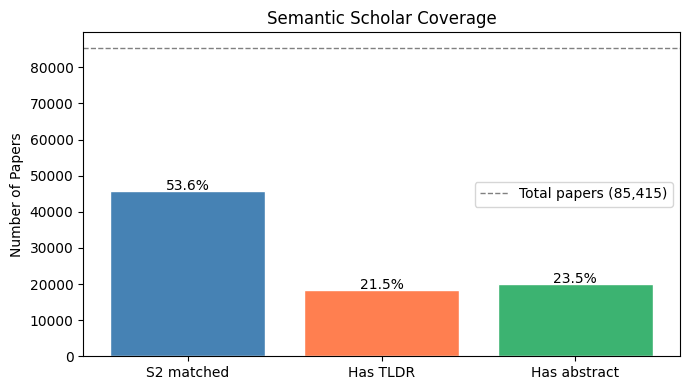

In [12]:
total = len(df)

n_s2_found = df.filter(pl.col("s2_found") == 1).shape[0]
n_tldr = df.filter(pl.col("tldr_text").is_not_null()).shape[0]
n_abstract = df.filter(pl.col("abstract_text").is_not_null()).shape[0]

print(f"Total papers:             {total:,}")
print(f"Matched in S2 (s2_found): {n_s2_found:,}  ({n_s2_found/total*100:.1f}%)")
print(f"With tldr_text:           {n_tldr:,}  ({n_tldr/total*100:.1f}%)")
print(f"With abstract_text:       {n_abstract:,}  ({n_abstract/total*100:.1f}%)")

# Coverage bar chart
labels = ["S2 matched", "Has TLDR", "Has abstract"]
counts = [n_s2_found, n_tldr, n_abstract]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, counts, color=["steelblue", "coral", "mediumseagreen"], edgecolor="white")
plt.axhline(total, color="gray", linestyle="--", linewidth=1, label=f"Total papers ({total:,})")
plt.title("Semantic Scholar Coverage")
plt.ylabel("Number of Papers")
plt.legend()
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{count/total*100:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 9. Summary & Takeaways

- **Citation count:** Extremely skewed — median is 0, mean is ~0.1. Since all papers are from 2026, very few have accumulated citations. Log transformation (`log1p`) improves the distribution shape but the near-zero signal means this may be a weak clustering feature. Consider dropping or treating it as a low-weight feature during preprocessing.
- **Author count:** Median 3, max 100, only 6 papers with 100+ authors. Clean distribution with no extreme outliers — a solid feature as-is.
- **Topics:** Only 11 unique subfields — very manageable. No collapsing needed. Top 5 subfields cover ~89% of papers. One-hot encoding is straightforward and won't balloon dimensionality.
- **Nulls:** Zero nulls in any OpenAlex column. No rows need to be dropped — the dataset is clean going into preprocessing.
- **Correlation:** Author count and citations have a Pearson correlation of -0.003 — effectively zero. No redundancy between these features; both can be kept.
- **Semantic Scholar coverage:** Only ~21% of papers have a TLDR and ~23% have an abstract. Recommend using these for dashboard display only, not as clustering features, due to sparse coverage.